In [25]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import os
proxy = 'http://127.0.0.1:7890' 
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

# Data acquisition and merging function

In [3]:
def option_chains(ticker):
    """
    Get and merge all option chain data for the specified stock ticker.
    """
    asset = yf.Ticker(ticker)
    
    # Get all expiration dates
    expirations = asset.options
    
    chains = pd.DataFrame()
    
    # Loop through each expiration date
    for expiration in expirations:
        # yfinance.option_chain() returns a tuple containing call and put option information
        opt = asset.option_chain(expiration)
        
        # Process call options
        calls = opt.calls
        calls['optionType'] = "call"
        
        # Process put options
        puts = opt.puts
        puts['optionType'] = "put"
        
        # Merge call and put options
        chain = pd.concat([calls, puts])
        # Set expiration time to the end of the day for easier day calculation
        chain['expiration'] = pd.to_datetime(expiration) + pd.DateOffset(hours=23, minutes=59, seconds=59)
        
        # Merge current expiration data into the overall dataset
        chains = pd.concat([chains, chain])
    
    # Calculate remaining days to expiration (+1 to include the current day)
    chains["daysToExpiration"] = (chains.expiration - dt.datetime.today()).dt.days + 1
    return chains

In [ ]:
# Get SPY option data
options = option_chains("SPY")
calls = options[options["optionType"] == "call"]

# Print all expiration dates
print(set(calls.expiration))

{Timestamp('2025-11-14 23:59:59'), Timestamp('2026-06-30 23:59:59'), Timestamp('2025-11-04 23:59:59'), Timestamp('2025-11-13 23:59:59'), Timestamp('2026-03-31 23:59:59'), Timestamp('2025-12-31 23:59:59'), Timestamp('2026-02-27 23:59:59'), Timestamp('2025-11-10 23:59:59'), Timestamp('2025-11-03 23:59:59'), Timestamp('2026-03-20 23:59:59'), Timestamp('2027-06-17 23:59:59'), Timestamp('2026-01-16 23:59:59'), Timestamp('2026-06-18 23:59:59'), Timestamp('2026-09-18 23:59:59'), Timestamp('2025-12-12 23:59:59'), Timestamp('2025-11-28 23:59:59'), Timestamp('2025-11-21 23:59:59'), Timestamp('2028-01-21 23:59:59'), Timestamp('2025-11-05 23:59:59'), Timestamp('2026-09-30 23:59:59'), Timestamp('2025-11-06 23:59:59'), Timestamp('2025-12-19 23:59:59'), Timestamp('2026-12-18 23:59:59'), Timestamp('2027-01-15 23:59:59'), Timestamp('2027-12-17 23:59:59'), Timestamp('2026-01-30 23:59:59'), Timestamp('2025-11-11 23:59:59'), Timestamp('2026-04-30 23:59:59'), Timestamp('2027-03-19 23:59:59'), Timestamp('20

# Analyze volatility skew and term structure

### Volatility Skew Analysis

<Axes: title={'center': 'Implied Volatility Skew'}, xlabel='strike'>

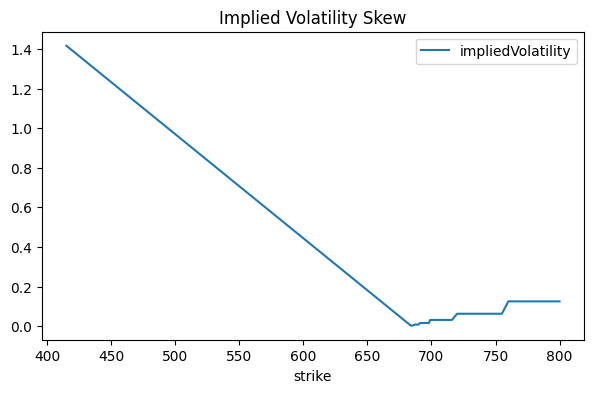

In [29]:
# Select an expiration date for plotting
calls_at_expiry = calls[calls["expiration"] == '2025-11-21 23:59:59']

# Filter out extremely low (possibly zero) volatility data to avoid outlier interference
filtered_calls_at_expiry = calls_at_expiry[calls_at_expiry.impliedVolatility >= 0.001]

# Plot implied volatility curve with strike price as index
filtered_calls_at_expiry[["strike", "impliedVolatility"]].set_index("strike").plot(
    title="Implied Volatility Skew", figsize=(7, 4))

### Volatility Term Structure Analysis

<Axes: title={'center': 'Implied Volatility Term Structure'}, xlabel='expiration'>

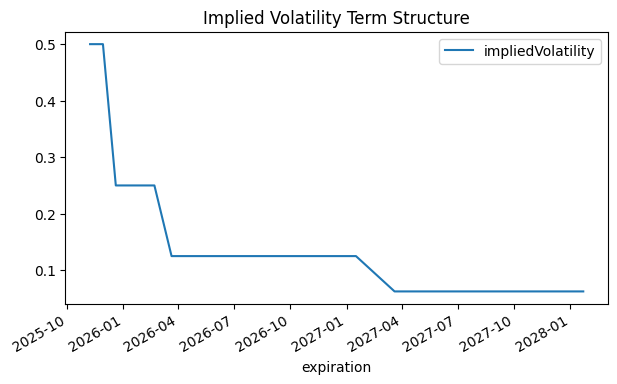

In [30]:
# Select a strike price for plotting (e.g., $400.0)
calls_at_strike = options[options["strike"] == 400.0]

# Filter out extremely low volatility
filtered_calls_at_strike = calls_at_strike[calls_at_strike.impliedVolatility >= 0.001]

# Plot implied volatility curve with expiration date as index
filtered_calls_at_strike[["expiration", "impliedVolatility"]].set_index("expiration").plot(
    title="Implied Volatility Term Structure", figsize=(7, 4))

# Plot 3D volatility surface

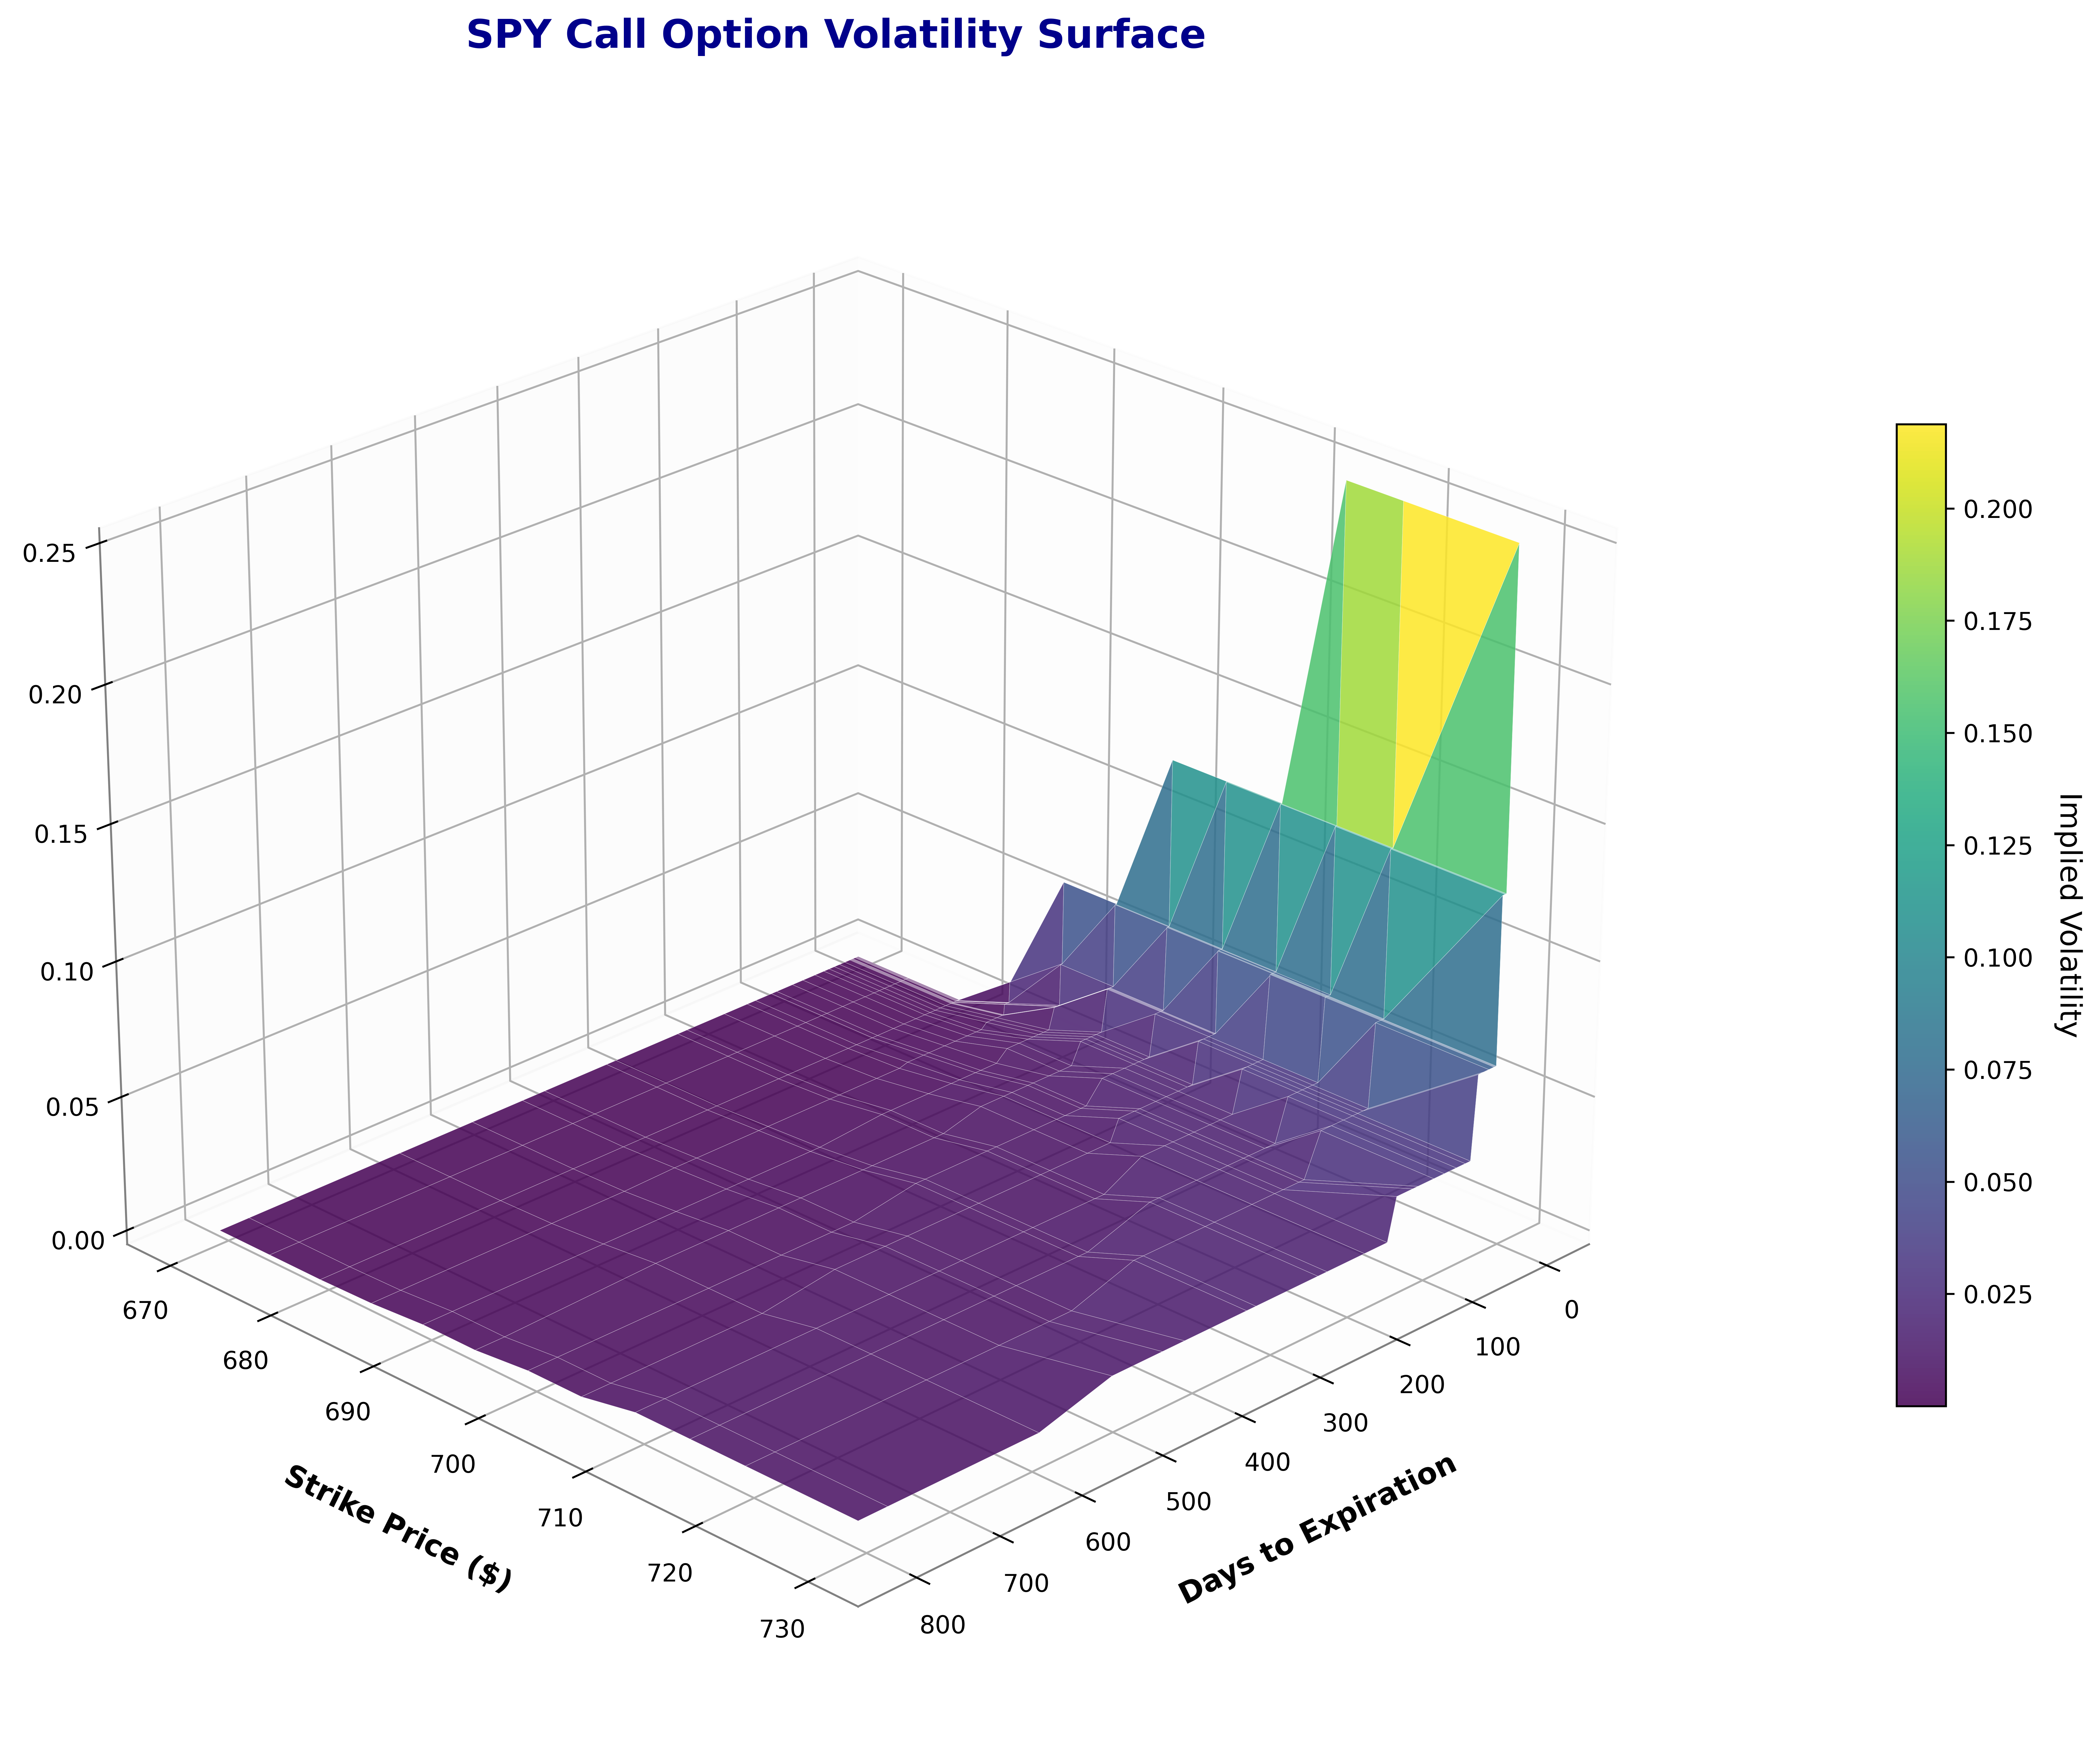

In [31]:
# 1. Data pivot: strike price as index, days to expiration as columns, implied volatility as values
surface = (
    calls[['daysToExpiration', 'strike', 'impliedVolatility']]
    .pivot_table(values='impliedVolatility', index='strike', columns='daysToExpiration')
    .dropna()
)

# 2. Create chart object
fig = plt.figure(figsize=(14, 10), dpi=600)
ax = fig.add_subplot(111, projection='3d')

# 3. Prepare plotting data
x, y = surface.columns.values, surface.index.values
z = surface.values
X, Y = np.meshgrid(x, y)

# 4. Plot surface
surf = ax.plot_surface(X, Y, z, 
                      cmap=cm.viridis,          # Color mapping
                      alpha=0.85,               # Transparency
                      linewidth=0.1,            # Grid line width
                      edgecolor='white',        # Grid line color
                      antialiased=True,         # Anti-aliasing
                      rstride=1, cstride=1,     # Grid density
                      shade=True)               # Shading effect

# 5. Add color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Implied Volatility', rotation=270, labelpad=20, fontsize=12)

# 6. Set labels and title
ax.set_xlabel('Days to Expiration', labelpad=15, fontsize=12, fontweight='bold')
ax.set_ylabel('Strike Price ($)', labelpad=15, fontsize=12, fontweight='bold')
ax.set_zlabel('Implied Volatility', labelpad=15, fontsize=12, fontweight='bold')
ax.set_title('SPY Call Option Volatility Surface', 
             pad=20, fontsize=16, fontweight='bold', color='darkblue')

# 7. Set grid and background
ax.grid(True, alpha=0.3, linestyle='--')  # Dashed grid
ax.xaxis.pane.set_alpha(0.1)  # Background panel transparency
ax.yaxis.pane.set_alpha(0.1)
ax.zaxis.pane.set_alpha(0.1)

# 8. Set viewing angle
ax.view_init(elev=25, azim=45)  

# 9. Add some beautification effects
# Set axis colors
ax.xaxis.line.set_color('gray')
ax.yaxis.line.set_color('gray')
ax.zaxis.line.set_color('gray')

# Set tick labels
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()